In [ ]:
import alphapepttools as at
import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad
import numpy as np
import mudata as md
from scipy.sparse._csr import csr_matrix
from scipy.sparse import triu
import networkx as nx

In [ ]:
mudata = md.read_h5mu("C:/Users/stock/Downloads/msdata/msdata/minimal1.h5mu")
mudata["precursors"].obs["group"] = ["A", "A", "A", "B", "B"]
mudata["precursors"].X = np.random.randint(5, 15, size=(5, 6))

c:\Users\stock\miniconda3\envs\hackathon\Lib\site-packages\mudata\_core\mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
c:\Users\stock\miniconda3\envs\hackathon\Lib\site-packages\mudata\_core\mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [269]:
def plot_peptide_intensities(
    mudata: md.MuData,
    obs_group: str,
    level: str = "precursors",
    figsize: tuple = (7, 8),
):
    """
    Generate a box plot of intensities between multiple conditions for all entities in an anndata object.

    Parameters:
        mudata: MuData
            Filtered MuData object, containing intensity data at different levels.
        obs_group: str
            The observation group to plot (must be a column name in mudata[level].obs).
        level:
            Name of the level in `mudata` that should be visualized. Default: "precursors".
    """
    fig, (ax_graph, ax_box) = plt.subplots(2, 1, figsize=figsize)
    plt.subplots_adjust(hspace=0)

    ### visualize graph on top
    # create a directed graph from the triangular adjacency matrix
    adj_directed = triu(mudata.varp["feature_mapping"], k=-1).tocsr()
    G = nx.from_scipy_sparse_array(adj_directed, create_using=nx.DiGraph)
    # label the nodes according to the index of mudata.var
    mapping = {i: mudata.var.index[i] for i in range(mudata.varp["feature_mapping"].shape[0])}
    G = nx.relabel_nodes(G, mapping, copy=False)

    pos = nx.nx_agraph.graphviz_layout(G, prog="dot", args="-Grankdir=BT")
    nx.draw_networkx(G, pos, with_labels=True, node_size=1000, node_color="grey", arrows=False, ax=ax_graph)
    ax_graph.axis("off")

    ### boxblot below
    # use dummy data instead of what's in mudata["precursors"] because the example data only contains 0 intensity values
    precursor_order = np.argsort(np.array(list(pos.values())[:mudata["precursors"].shape[1]])[:, 0])
    df = mudata[level][:, precursor_order].to_df() # reorder anndata so that the boxes are in the same order as the leaves
    df["group"] = mudata[level].obs[obs_group]
    df_melt = df.melt(id_vars="group", var_name="peptide", value_name="intensity")

    sns.boxplot(x="peptide", y="intensity", hue="group", data=df_melt, ax=ax_box)
    ax_box.tick_params("x", rotation=90)

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
c:\Users\stock\miniconda3\envs\hackathon\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
c:\Users\stock\miniconda3\envs\hackathon\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


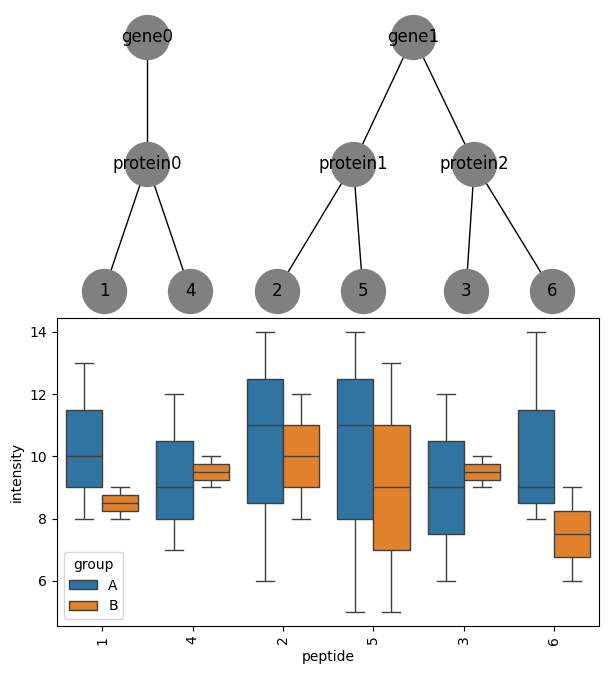

In [270]:
plot_peptide_intensities(mudata, "group")